<a href="https://colab.research.google.com/github/MartinTiong/CPE-311/blob/main/Hands_on_Activity_9_1_Data_Visualization_using_Pandas_and_Matplotlib_TIONG_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

9.1 Introduction to Matplotlib

In [2]:
!pip install matplotlib-venn

In [5]:
import matplotlib.pyplot as plt
import pandas as pd


Plotting lines

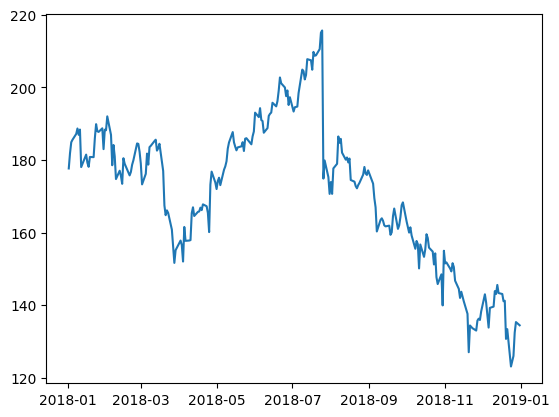

In [9]:
fb = pd.read_csv('/content/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

plt.plot(fb.index, fb.open)
plt.show()

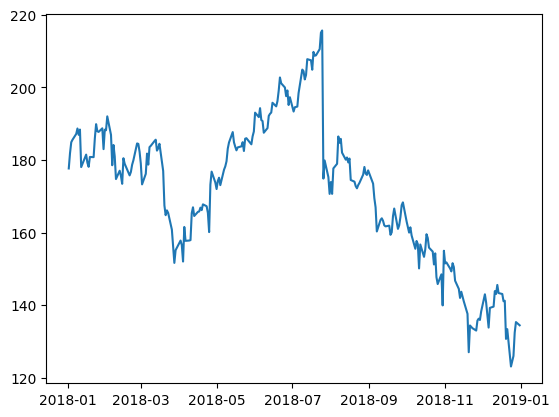

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

fb = pd.read_csv( '/content/fb_stock_prices_2018.csv', index_col='date', parse_dates= True)
plt.plot(fb.index, fb.open)

Scatter plots

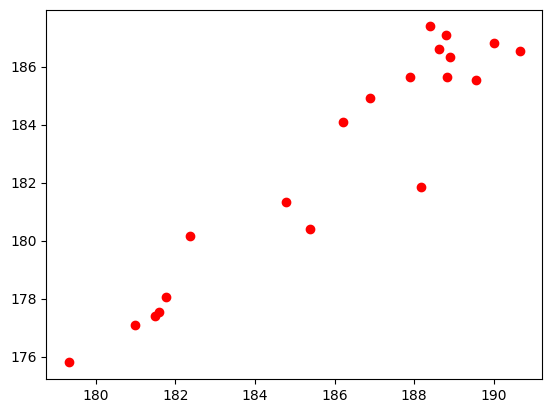

In [14]:
plt.plot('high', 'low', 'ro', data=fb.head(20))

Histograms

(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

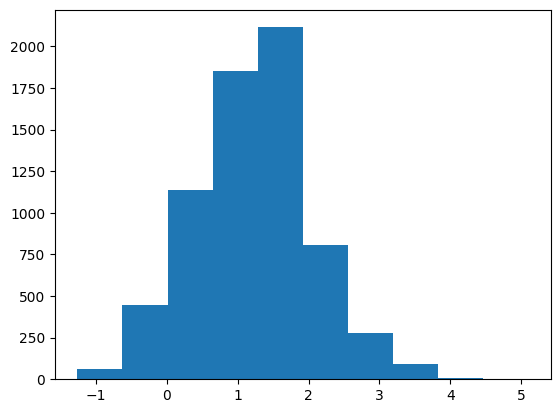

In [15]:
quakes = pd.read_csv('/content/earthquakes-1.csv')
plt.hist(quakes.query('magType == "ml"').mag)

Bin size matters

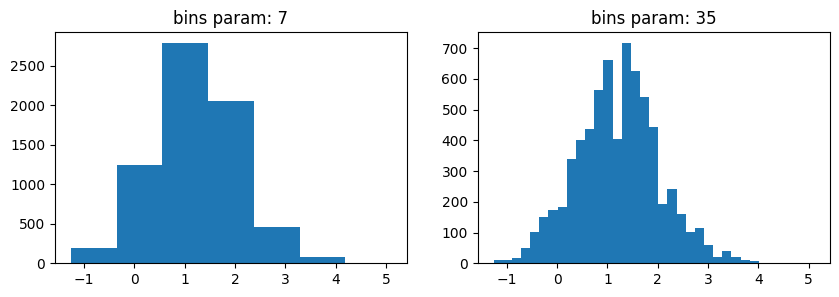

In [17]:
x= quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10,3))
for ax, bins in zip(axes, [7, 35]):
  ax.hist(x, bins=bins)
  ax.set_title(f'bins param: {bins}')

Plot components

Figure

In [18]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

Axes

Individual plots contained within the Figure

Creating subplots

Simply specify the number of rows and columns to create:

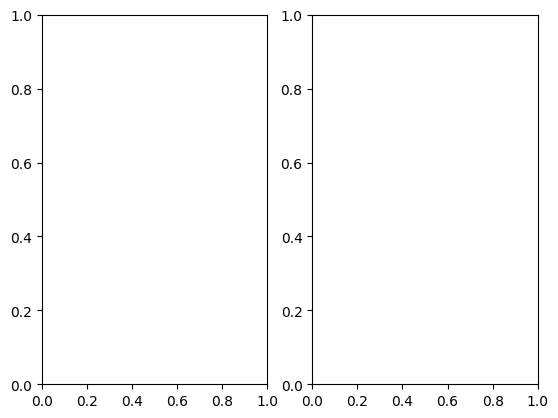

In [19]:
fig, axes = plt.subplots(1, 2)

As an alternative to using plt.subplots() we can add the Axes to the Figure on our own. This allows for some more complex layouts, such as picture in picture:

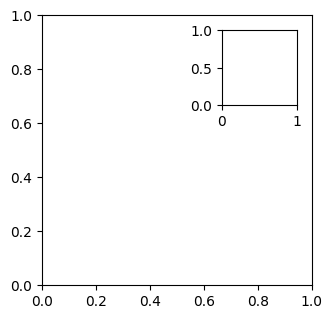

In [20]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])

Creating Plot Layouts with gridspec

We can create subplots with varying sizes as well:

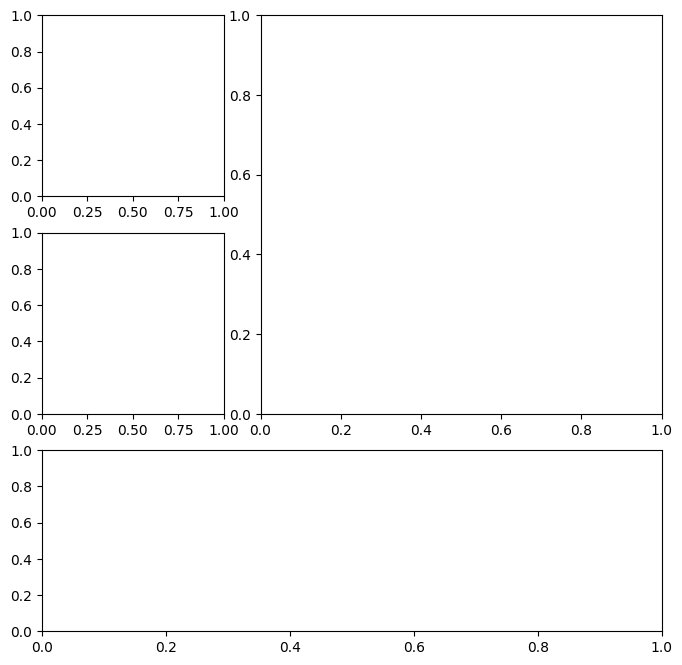

In [21]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

Saving plots

Use plt.savefig() to save the last created plot. To save a specific Figure object, use its savefig() method.

In [22]:
fig.savefig('empty.png')

Cleaning up

It's important to close resources when we are done with them. We use plt.close() to do so. If we pass in nothing, it will close the last plot, but we can pass the specific
Figure to close or say 'all' to close all Figure objects that are open. Let's close all the Figure objects that are open with plt.close() :

In [23]:
plt.close('all')

Additional plotting options

Specifying figure size

Just pass the figsize parameter to plt.figure() . It's a tuple of (width, height):

In [24]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

This can be specified when creating subplots as well:

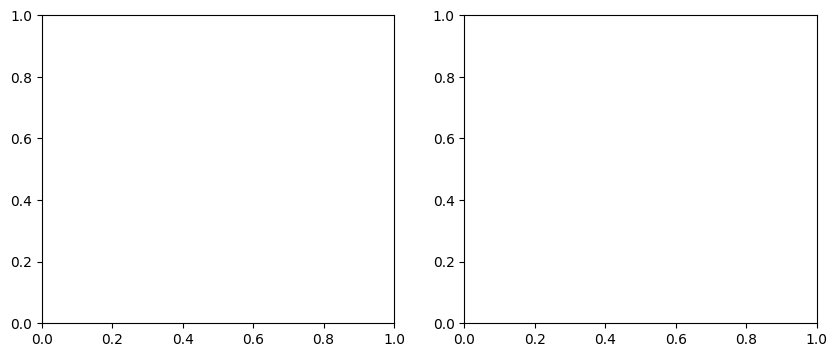

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

rcParams

A small subset of all the available plot settings (shuffling to get a good variation of options):

In [26]:
import random
import matplotlib as mpl
rcparams_list = list(mpl.rcParams.keys())
random.seed(20) # make this repeatable
random.shuffle(rcparams_list)
sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

We can check the current default figsize using rcParams :

In [27]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]


We can also update this value to change the default (until the kernel is restarted)

In [28]:
mpl.rcParams['figure.figsize'] = (300, 10)
mpl.rcParams['figure.figsize']

[300.0, 10.0]

Use rcdefaults() to restore the defaults

In [29]:
mpl.rcdefaults()
mpl.rcParams['figure.figsize']

[6.4, 4.8]

This can also be done via pyplot :

In [30]:
plt.rc('figure', figsize=(20, 20)) # change figsize default to (20, 20)
plt.rcdefaults() # reset the default

Data analysis:

This procedure gave us a refresher about the foramtion od different plots using matplotlib, along with the adjustments that can be made in each aforementioned plots.

9.2 Plotting with Pandas

The plot() method is available on Series and DataFrame objects. Many of the parameters get passed down to matplotlib. The kind argument let's us vary the plot
type.

Setup

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'/content/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('/content/earthquakes-1.csv')

Evolution over time

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

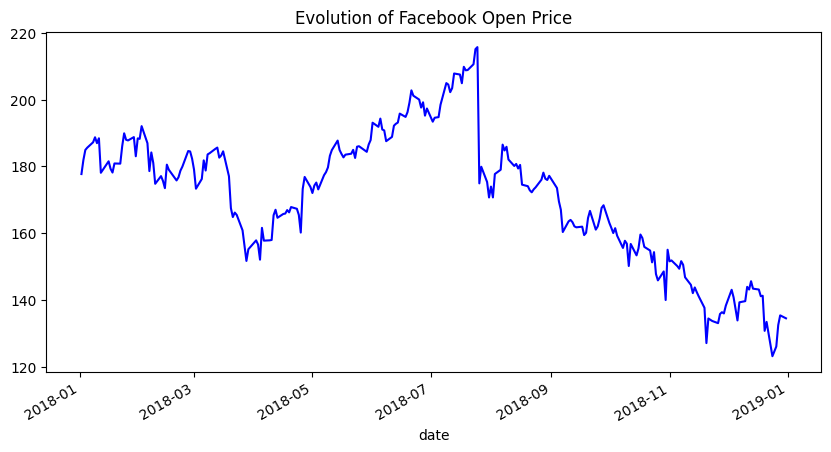

In [35]:
fb.plot(
kind='line',
y='open',
figsize=(10, 5),
style='b-',
legend=False,
title='Evolution of Facebook Open Price')

We provided the style argument in the previous example; however, we can use the color and linestyle arguments to get the same result:

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

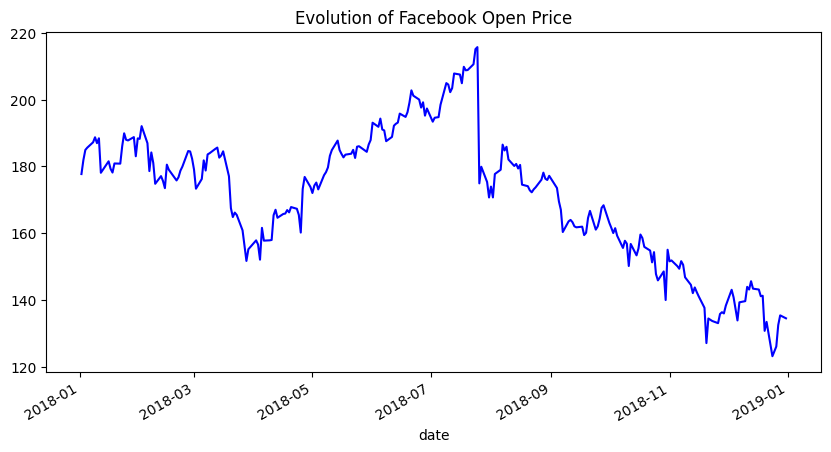

In [36]:
fb.plot(
kind='line',
y='open',
figsize=(10, 5),
color='blue',
linestyle='solid',
legend=False,
title='Evolution of Facebook Open Price')

<Axes: title={'center': 'Facebook OHLC Prices during 1st Week of Trading 2018'}, xlabel='date'>

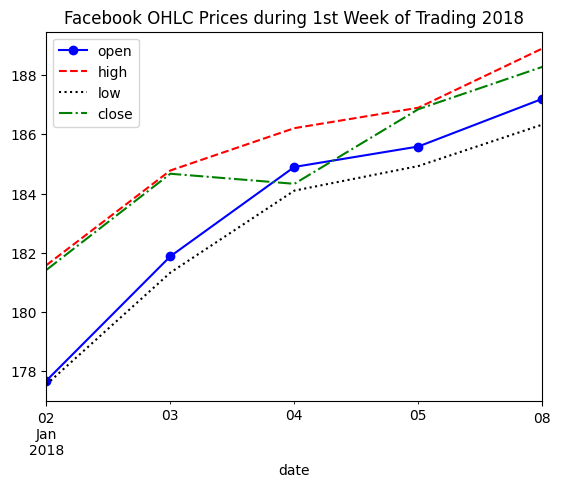

In [37]:
fb.iloc[:5,].plot(
y=['open', 'high', 'low', 'close'],
style=['b-o', 'r--', 'k:', 'g-.'],
title='Facebook OHLC Prices during 1st Week of Trading 2018'
)

Creating subplots

When plotting with pandas, creating subplots is simply a matter of passing subplots=True to the plot() method, and (optionally) specifying the layout in a tuple of
(rows, columns) :

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

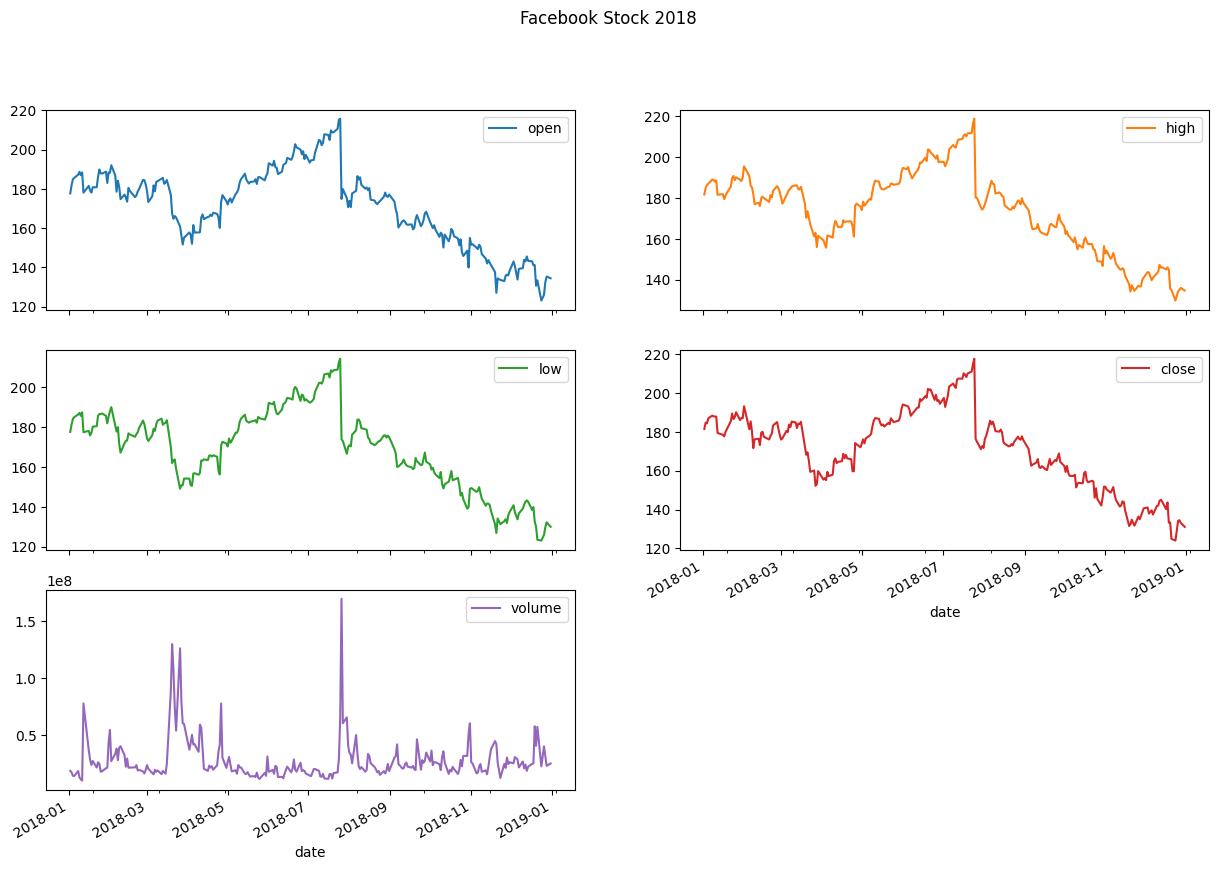

In [38]:
fb.plot(
kind='line',
subplots=True,
layout=(3,2),
figsize=(15,10),
title='Facebook Stock 2018'
)

Visualizing relationships between variables

Scatter plots

We make scatter plots to help visualize the relationship between two variables. Creating scatter plots requires we pass in kind='scatter' along with a column for the x-
axis and a column for the y-axis:

<Axes: title={'center': 'Facebook Daily High - Low vs.Volume Traded'}, xlabel='volume', ylabel='max_abs_change'>

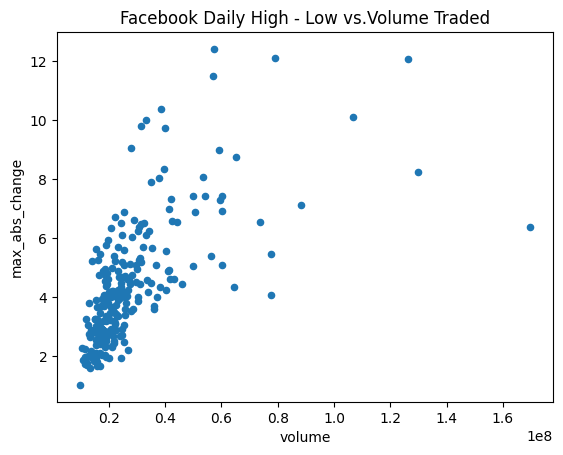

In [39]:
fb.assign(
max_abs_change=fb.high - fb.low
           ).plot(kind='scatter', x='volume', y='max_abs_change',
                  title='Facebook Daily High - Low vs.Volume Traded')

The relationship doesn't seem to be linear, but we can try a log transform on the x-axis since the scales of the axes are very different. With pandas, we simply pass in
logx=True :

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

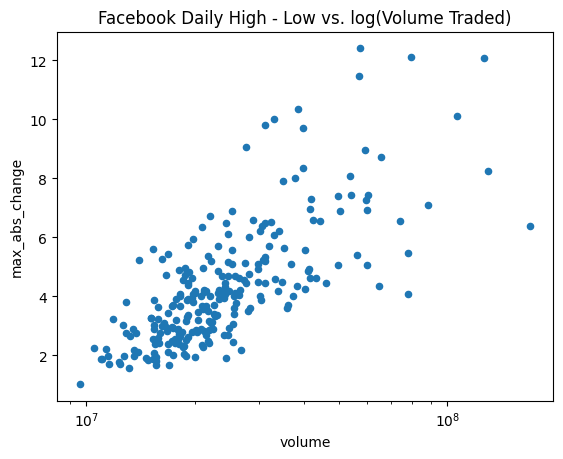

In [40]:
fb.assign(
max_abs_change=fb.high - fb.low
).plot(
kind='scatter', x='volume', y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
logx=True
)

Adding Transparency to Plots with alpha
Sometimes our plots have many overlapping values, but this can be impossible to see. This can be addressed by increasing the transparency of what we are plotting using the
alpha parameter. It is a float on [0, 1] where 0 is completely transparent and 1 is completely opaque. By default this is 1, so let's put in a lower value and re-plot the scatter
plot:

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

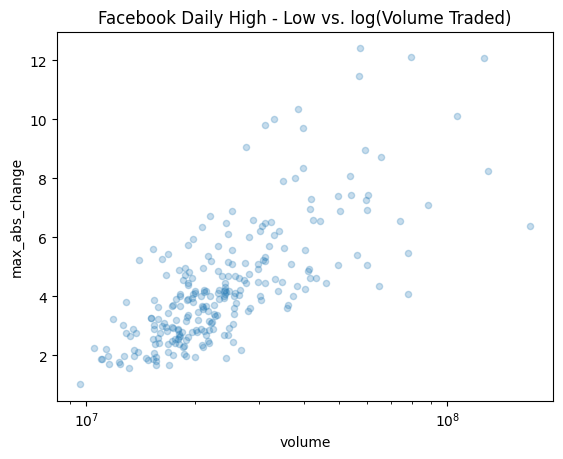

In [41]:
fb.assign(
max_abs_change=fb.high - fb.low
).plot(
kind='scatter', x='volume', y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
logx=True, alpha=0.25
)

Hexbins
In the previous example, we can start to see the overlaps, but it is still difficult. Hexbins are another plot type that divide up the plot into hexagons, which are shaded
according to the density of points there. With pandas, this is the hexbin value for the kind argument. It can also be important to tweak the gridsize , which determines
the number of hexagons along the y-axis:

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='log_volume', ylabel='max_abs_change'>

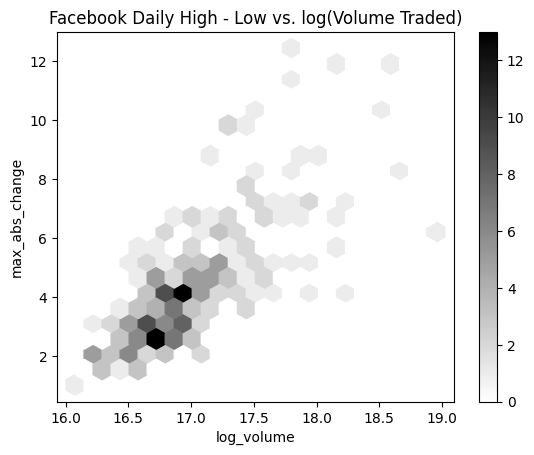

In [42]:
fb.assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).plot(
kind='hexbin',
x='log_volume',
y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
colormap='gray_r',
gridsize=20,
sharex=False # we have to pass this to see the x-axis due to a bug in this version of pandas
)

Visualizing Correlations with Heatmaps
Pandas doesn't offer heatmaps; however, if we are able to get our data into a matrix, we can use matshow() from matplotlib:

AttributeError: 'Colorbar' object has no attribute 'set_clim'

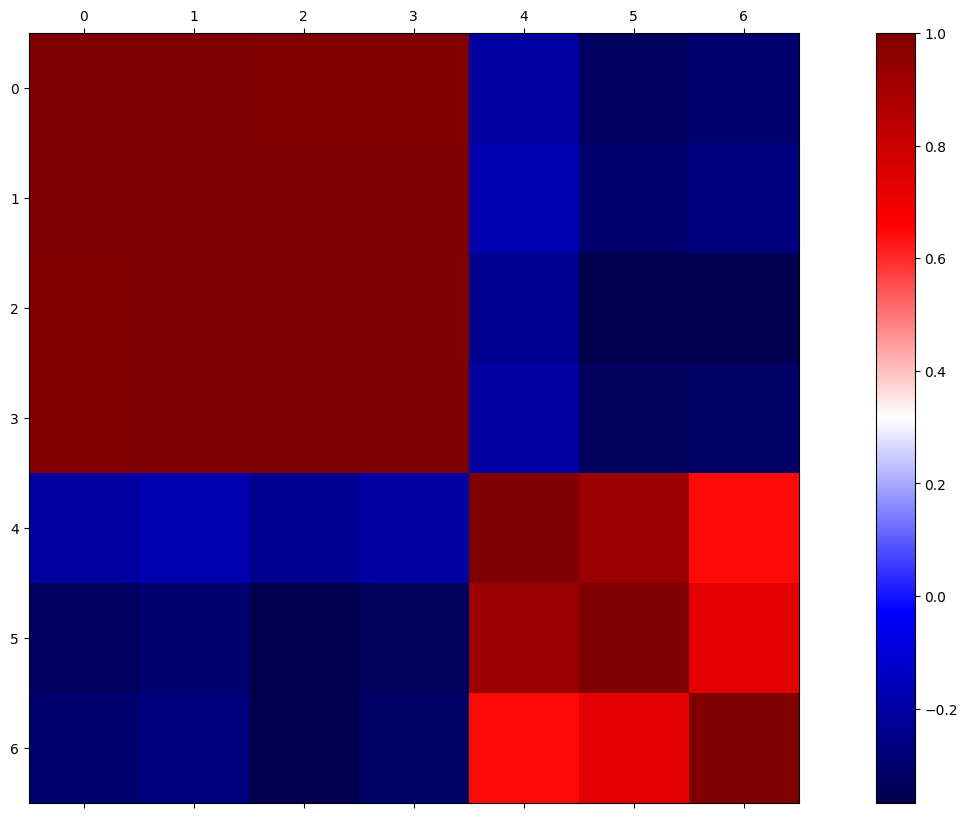

In [43]:
fig, ax = plt.subplots(figsize=(20, 10))
fb_corr = fb.assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).corr()
im = ax.matshow(fb_corr, cmap='seismic')
fig.colorbar(im).set_clim(-1, 1)
labels = [col.lower() for col in fb_corr.columns]
ax.set_xticklabels([''] + labels, rotation=45)
ax.set_yticklabels([''] + labels)

In [44]:
fb_corr.loc['max_abs_change', ['volume', 'log_volume']]

,max_abs_change
volume,0.642027
log_volume,0.731542


Visualizing distributions
Histograms
With the pandas plot() method, making histograms is as easy as passing in kind='hist' :

Text(0.5, 0, 'Volume traded')

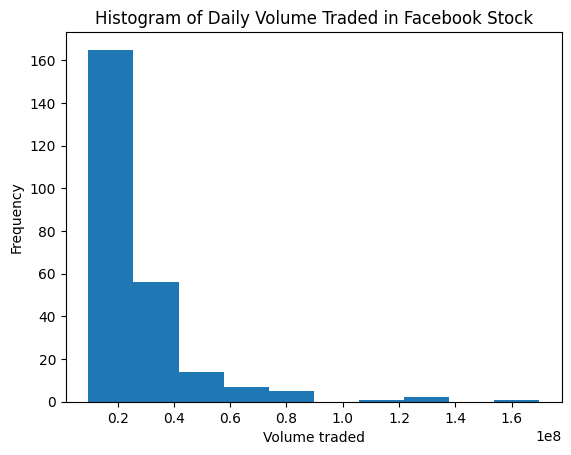

In [45]:
fb.volume.plot(
kind='hist',
title='Histogram of Daily Volume Traded in Facebook Stock'
)
plt.xlabel('Volume traded') # label the x-axis (discussed in chapter 6)